In [1]:
%load_ext autoreload
%autoreload 2
from pathlib import Path
import zipfile
import librosa
import torch
import numpy as np
from SMT import *
from sklearn.cluster import MiniBatchKMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize
from tqdm import tqdm
import json
import torchaudio
from kmeans import *
from ctc import *
from smtlstm import *


grid_search:   0%|          | 0/875 [00:00<?, ?it/s]

patch utterances
apply kmeans


grid_search:   0%|          | 1/875 [01:06<16:07:46, 66.44s/it]

patch utterances
apply kmeans


grid_search:   0%|          | 1/875 [01:43<25:09:44, 103.64s/it]


KeyboardInterrupt: 

In [2]:
librispeech_ds = torchaudio.datasets.LIBRISPEECH(
    root=str("./data/"), url="dev-clean", download=True,
)
#results = grid_search(librispeech_ds)

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
audio_features = extract_features_from_dataset(librispeech_ds, 
                                                500, 
                                                20,
                                                window_ms=10, hop_ms=5)

# this is kinda stupid, just do this in the previous function
mels = [clip["mel_spectrogram"] for _, clip in audio_features.items()]
mfccs = [clip["mfcc"] for _, clip in audio_features.items()]
log_mels = [clip["log_mel_db"] for _, clip in audio_features.items()]
hop_length = [clip["hop_length"] for _, clip in audio_features.items()][0]
sr = [clip["sr"] for _, clip in audio_features.items()][0]

# patch and preprocess
patches, utterance_bounds = patch_multiple_utterances(log_mels, sr, hop_length, 50, patch_frame_hop=1)
norm_patches, mean, zcaMatrix = preprocess_patches(patches)
# kmeans = apply_kmeans_to_patches(norm_patches, 3000)

# kmeans for sparse coding
labels, centroids, inertia, counts = minibatch_kmeans_gpu_vectorized(
    torch.tensor(norm_patches).to(device),
    n_clusters=3000,
    batch_size=8192,
    n_iters=1000,
    n_init=3,
    distance="euclidean",
    init="kmeans++",
    reassignment_ratio=0.01,
    reassignment_freq=25,
    final_reassign=True,
    final_batch_size=16384,
    verbose=False,
)

100%|██████████| 3/3 [02:02<00:00, 40.89s/it]


In [4]:
#centroids = kmeans.cluster_centers_
plot_first_n_mel_patches(centroids[:].cpu().reshape(centroids[:].shape[0], 20, 30), 500, cols=10)

RuntimeError: shape '[3000, 20, 30]' is invalid for input of size 300000

In [10]:
k_sparse_coder = TopKSparseCoder(centroids.to(dtype=torch.float32), 16, 100, True, True)

patch_tensor1 = torch.tensor(norm_patches[:200]).to(dtype=torch.float32).to(device)
sparse_codes1 = k_sparse_coder(patch_tensor1)

patch_tensor2 = torch.tensor(norm_patches[200:]).to(dtype=torch.float32).to(device)
sparse_codes2 = k_sparse_coder(patch_tensor2)

OutOfMemoryError: CUDA out of memory. Tried to allocate 7.37 GiB. GPU 0 has a total capacity of 23.55 GiB of which 4.56 GiB is free. Including non-PyTorch memory, this process has 18.94 GiB memory in use. Of the allocated memory 15.74 GiB is allocated by PyTorch, and 2.88 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [6]:
values, indices = torch.topk(sparse_codes.sum(0), 100)


In [ ]:
centroids = centroids.to(device)

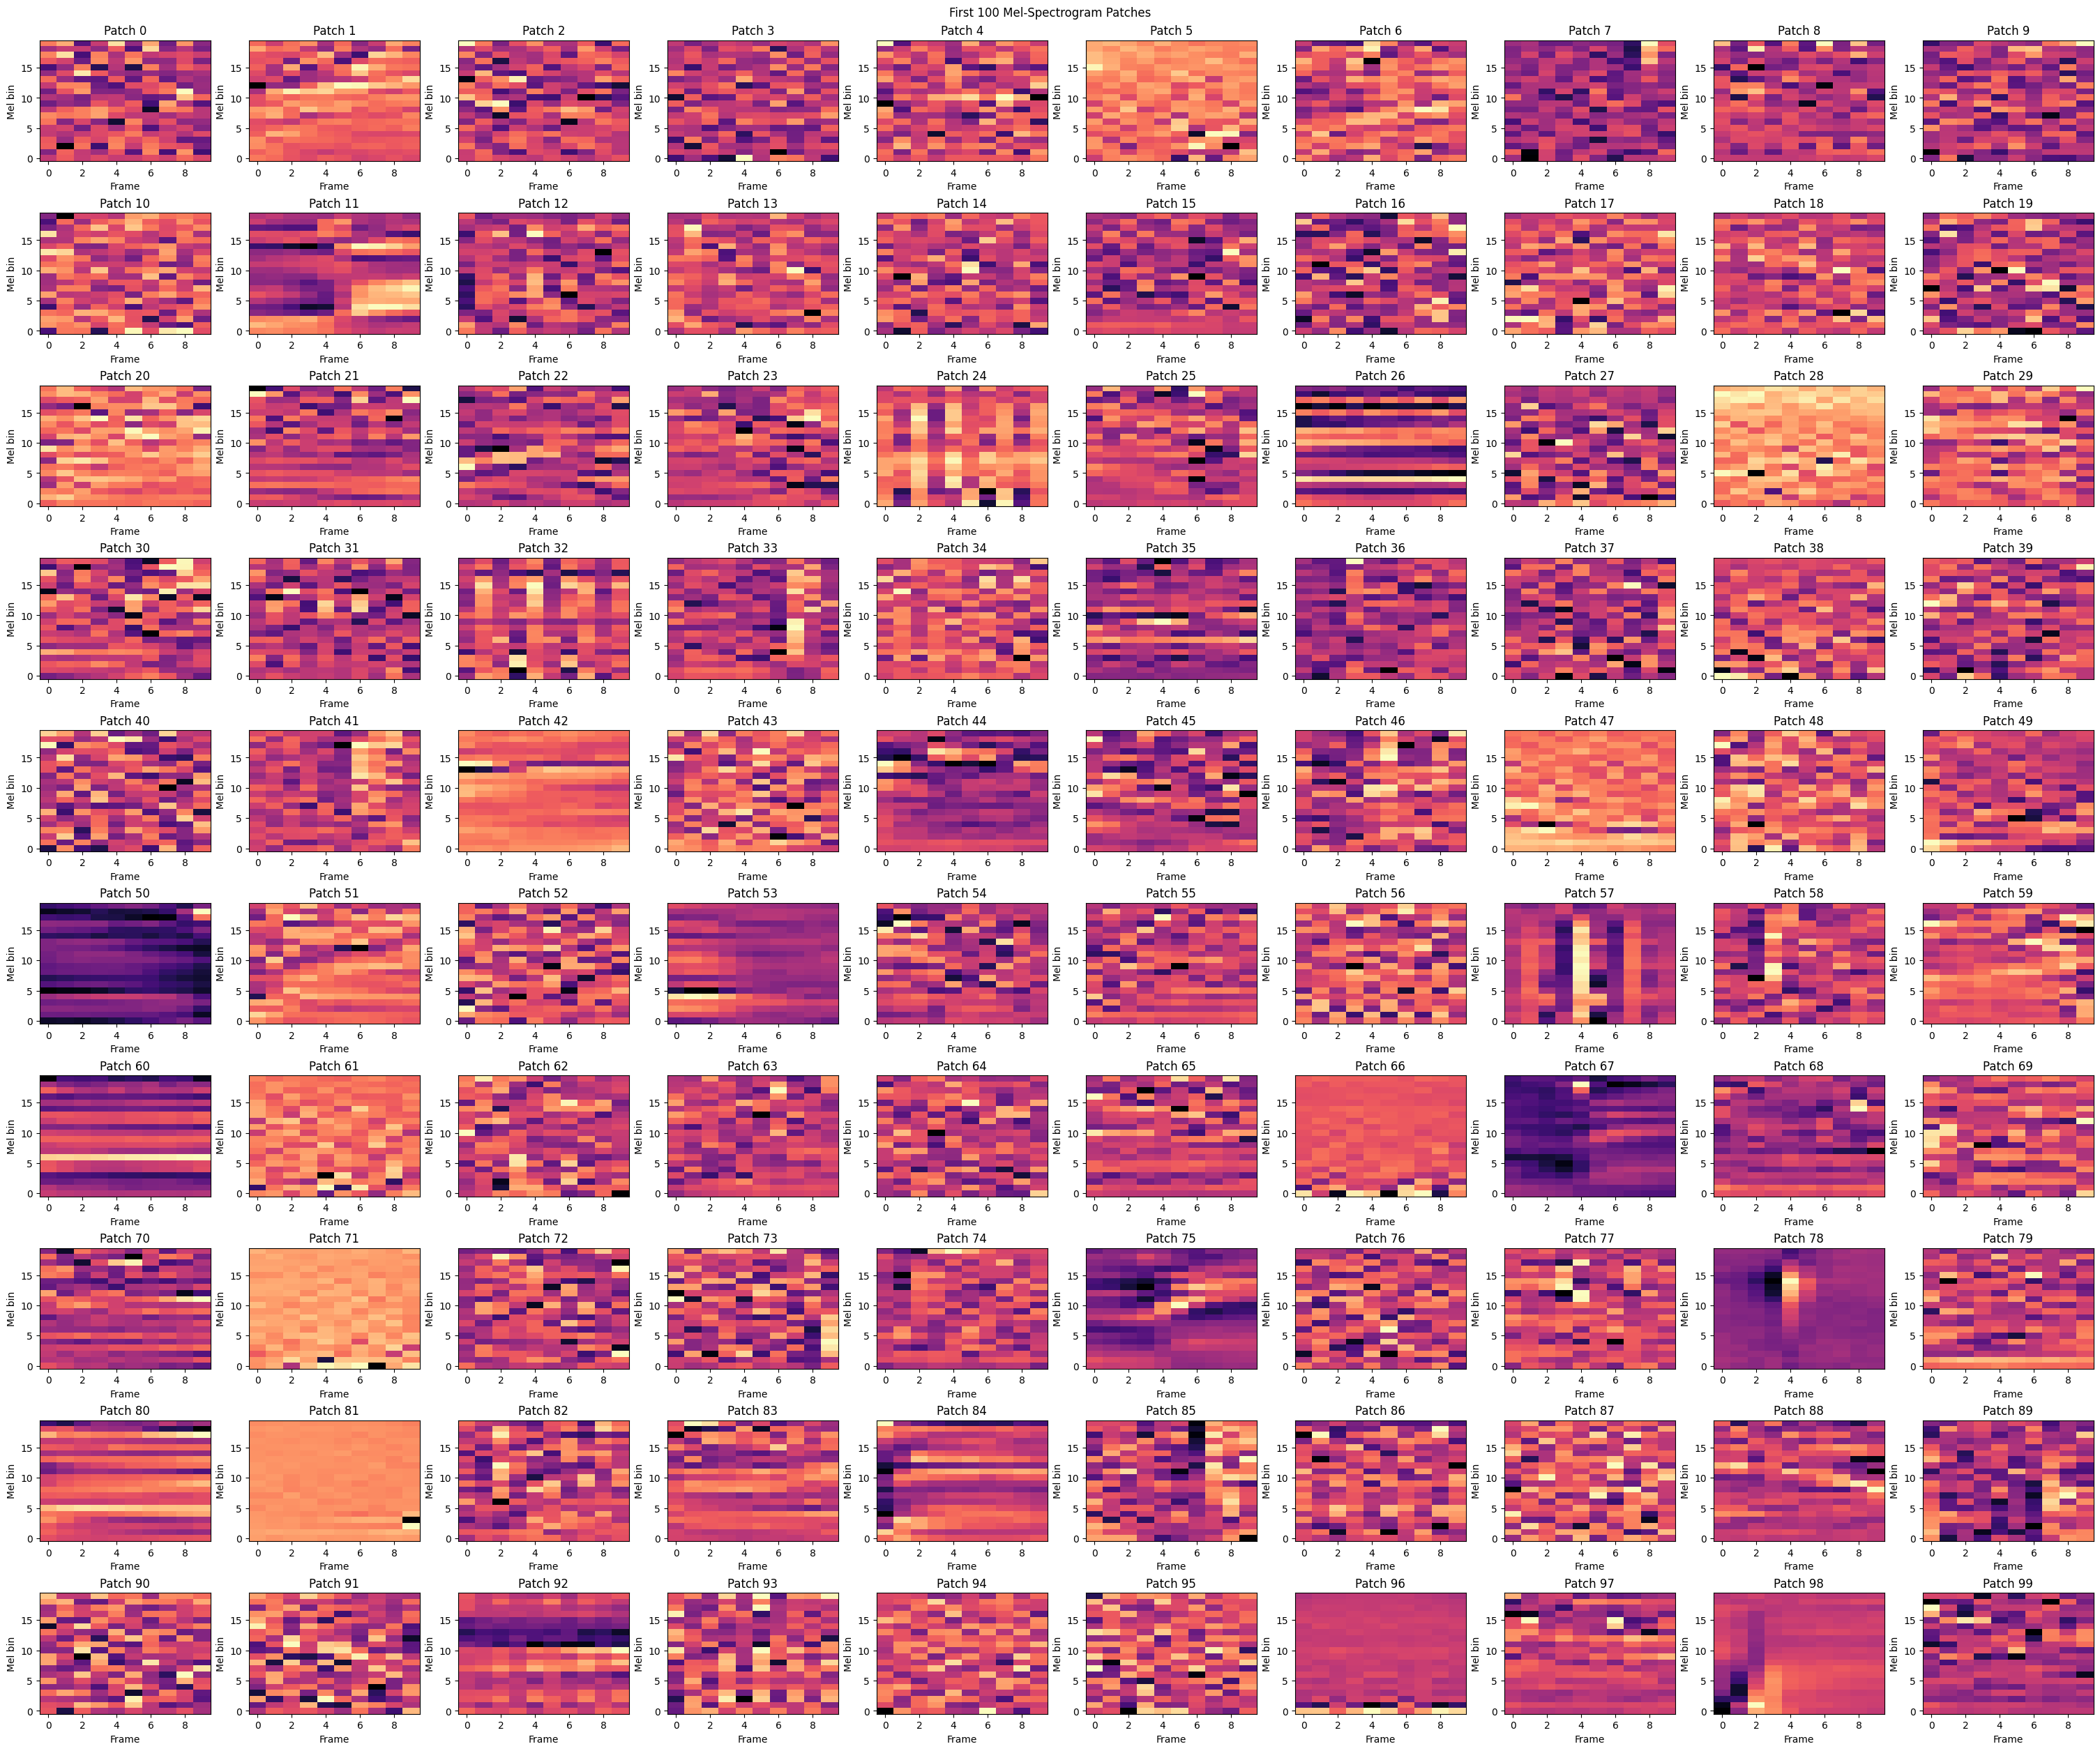

In [12]:
plot_first_n_mel_patches(centroids[indices,:].cpu().reshape(centroids[indices,:].shape[0], 20, 10), 100, cols=10)

In [ ]:
eigvals, eigvecs = spectral_decomp_dense_second_order_torch(sparse_codes, utterance_bounds)

# take smallest d eigenvectors as P
d=256
P = eigvecs[:, 1:d+1].T

beta = P@sparse_codes.T
norm_beta, _, _ = preprocess_patches(beta.T.cpu().numpy()) # this switches beta to be NxD like norm_patches
norm_beta = norm_beta


In [ ]:
smt_stats, mel_stats = calc_metrics_per_utterance(norm_patches, norm_beta, utterance_bounds, 6)

metrics:   0%|          | 0/500 [00:00<?, ?it/s]

metrics:  25%|██▍       | 124/500 [00:01<00:03, 112.16it/s]/home/zbalkhy/EEC289/final_project/SMT.py:521: RuntimeWarning: divide by zero encountered in scalar divide
  z_score_smooth = (obs_grad_median - np.mean(perm_grad_medians)) / np.std(perm_grad_medians)


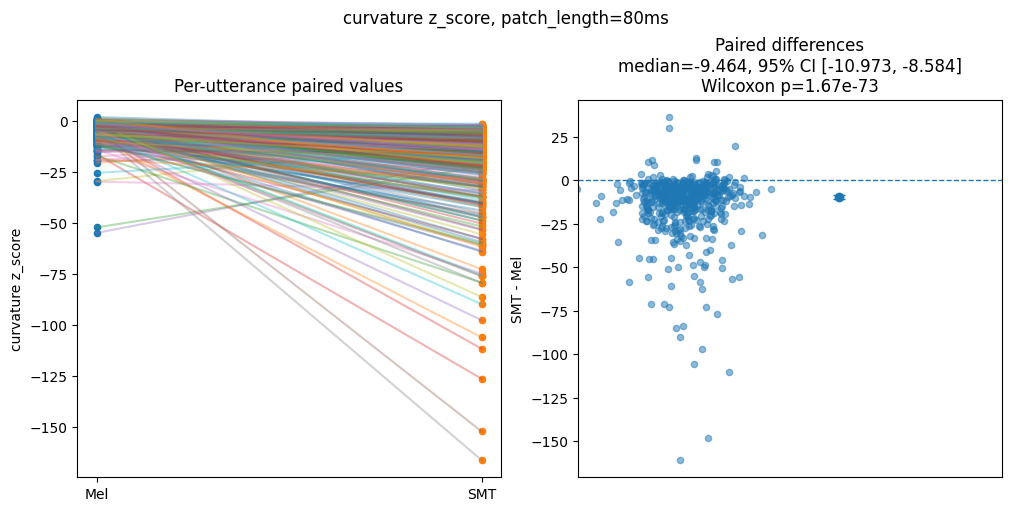

(np.float64(4128.0),
 np.float64(1.6676634431720836e-73),
 np.float64(-9.464028355598803),
 (np.float64(-10.973124118309967), np.float64(-8.583702365967776)))

In [ ]:
plot_paired_comparison(mel_stats['z_score_linear'], smt_stats['z_score_linear'], 80, 'curvature z_score', 'less')

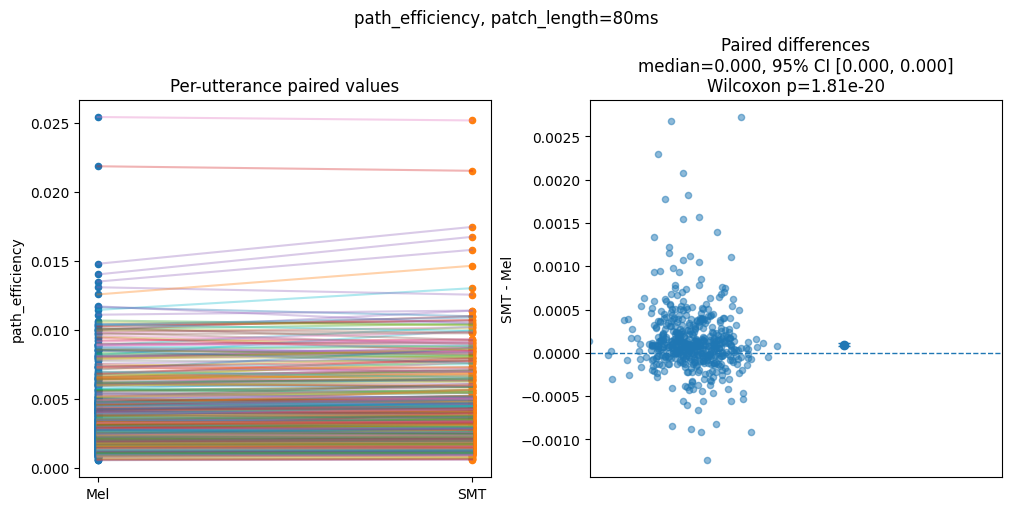

(np.float64(92358.0),
 np.float64(1.8126055049423716e-20),
 np.float64(8.975946635694527e-05),
 (np.float64(7.50148220187998e-05), np.float64(0.00010906779349944781)))

In [ ]:
plot_paired_comparison(mel_stats['path_efficiency'], smt_stats['path_efficiency'], 80, 'path_efficiency', 'greater')

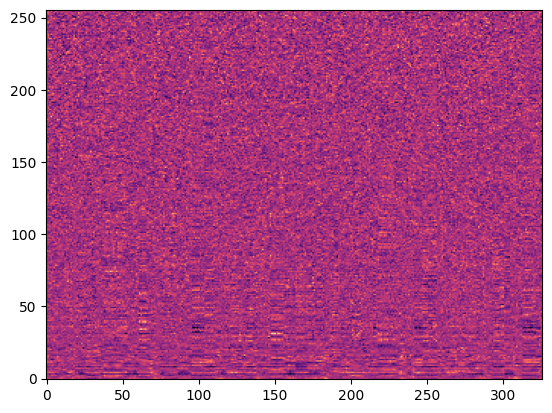

In [ ]:
(start, end) = utterance_bounds[0]
norm_beta[start:end].shape

plt.imshow(norm_beta[start:end].T, origin='lower', aspect='auto', cmap="magma")

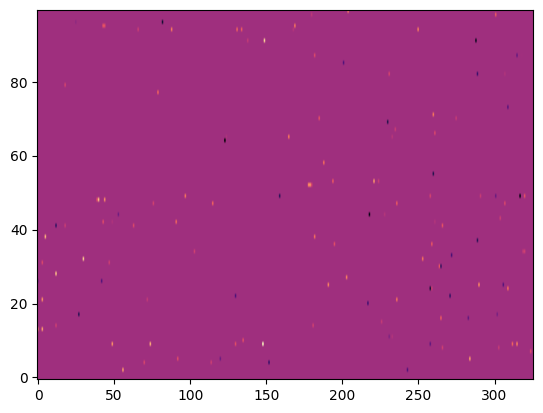

In [ ]:
plt.imshow(sparse_codes[start:end,indices].cpu().numpy().T, origin='lower', aspect='auto', cmap="magma")

In [ ]:
import re
from g2p_en import G2p


def make_dataloader(dataset, tokenizer, batch_size=16, shuffle=True, num_workers=0):
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        collate_fn=lambda batch: ctc_collate_fn(batch, tokenizer),
    )

class NormBetaDataset(Dataset):
    """Simple utterance-level dataset built from norm_beta and utterance bounds."""
    def __init__(self, norm_beta: np.ndarray, utterance_bounds, texts=None):
        self.norm_beta = norm_beta
        self.utterance_bounds = list(utterance_bounds)
        self.g2p = G2p()
        if texts is None:
            self.texts = [""] * len(self.utterance_bounds)
        else:
            if len(texts) != len(self.utterance_bounds):
                raise ValueError("texts must match utterance_bounds length")
            self.texts = list(texts)

    def __len__(self):
        return len(self.utterance_bounds)

    def __getitem__(self, idx):
        start, end = self.utterance_bounds[idx]
        x = torch.as_tensor(self.norm_beta[start:end, :], dtype=torch.float32)
        return {
            "features": x,
            "text": self._text_to_phonemes(self.texts[idx]),
        }
    
    def _text_to_phonemes(self, text, remove_stress=True):
        phonemes = self.g2p(text)

        # remove spaces/punctuation tokens
        phonemes = [p for p in phonemes if p.strip()]

        if remove_stress:
            phonemes = [p.rstrip("012") for p in phonemes]

        return phonemes

texts = [re.sub(r"[^a-z0-9\s]", "", librispeech_ds.get_metadata(idx)[2].lower()) for idx in range(len(utterance_bounds))]

data_length = len(utterance_bounds)
train_split =int(data_length*0.8)
train_bounds = utterance_bounds[:train_split]
train_text = texts[:train_split]
val_bounds = utterance_bounds[train_split:]
val_text = texts[train_split:]
train_dataset = NormBetaDataset(norm_beta, train_bounds, train_text)
val_dataset = NormBetaDataset(norm_beta, val_bounds, val_text)

PHONEMES = [
'AA','AE','AH','AO','AW','AY','EH','ER','EY','IH','IY',
'OW','OY','UH','UW',
'P','B','T','D','K','G',
'CH','JH',
'F','V','TH','DH','S','Z','SH','ZH','HH',
'M','N','NG',
'L','R','W','Y'
]
tokenizer = CharTokenizer(alphabet=PHONEMES, phonemes=True)
train_loader = make_dataloader(train_dataset, tokenizer, batch_size=40, shuffle=True)
val_loader = make_dataloader(val_dataset, tokenizer, batch_size=40, shuffle=False)

# Infer input dimension from one sample
sample = train_dataset[0]["features"]
d_in = sample.shape[1]

model = SMTCTCBiLSTM(
    d_in=d_in,
    vocab_size=tokenizer.vocab_size,
    hidden_size=256,
    dropout=0.1,
    use_layernorm=True,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

best_state = train_ctc_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    tokenizer=tokenizer,
    device=device,
    num_epochs=50,
    lr=1e-3,
    weight_decay=1e-4,
    grad_clip_norm=5.0,
)

if best_state is not None:
    torch.save(best_state, "best_smt_ctc_linear.pt")
    print(f"Saved best checkpoint with val CER={best_state['val_cer']:.4f}")

Epoch 001 | train_loss=16.2828 train_CER=1.7734 train_WER=0.0000 || val_loss=5.1655 val_CER=0.9992 val_WER=0.0000
Epoch 002 | train_loss=4.7298 train_CER=0.9998 train_WER=0.0000 || val_loss=3.9263 val_CER=0.9999 val_WER=0.0000
Epoch 003 | train_loss=3.6717 train_CER=0.9998 train_WER=0.0000 || val_loss=3.4887 val_CER=1.0000 val_WER=0.0000
Epoch 004 | train_loss=3.4888 train_CER=1.0000 train_WER=0.0000 || val_loss=3.5682 val_CER=1.0000 val_WER=0.0000
Epoch 005 | train_loss=3.4401 train_CER=1.0000 train_WER=0.0000 || val_loss=3.4698 val_CER=1.0000 val_WER=0.0000
Epoch 006 | train_loss=3.4196 train_CER=1.0000 train_WER=0.0000 || val_loss=3.5112 val_CER=1.0000 val_WER=0.0000
Epoch 007 | train_loss=3.4064 train_CER=1.0000 train_WER=0.0000 || val_loss=3.4684 val_CER=1.0000 val_WER=0.0000
Epoch 008 | train_loss=3.4001 train_CER=1.0000 train_WER=0.0000 || val_loss=3.4866 val_CER=1.0000 val_WER=0.0000
Epoch 009 | train_loss=3.3915 train_CER=1.0000 train_WER=0.0000 || val_loss=3.4756 val_CER=1.00

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = CharTokenizer(alphabet=PHONEMES, phonemes=True)

model = load_trained_bilstm_model(
    checkpoint_path="best_smt_ctc_linear.pt",
    d_in=d_in,
    vocab_size=tokenizer.vocab_size,
    device=device,
)

for sample in val_dataset:


    pred = predict_one(
        model=model,
        features=sample["features"],
        tokenizer=tokenizer,
        device=device,
        return_confidence=True,
    )

    print("Reference :", sample["text"])
    print("Predicted :", pred["text"])
    print("Confidence:", pred["confidence"])

Reference : ['AY', 'T', 'OW', 'L', 'D', 'T', 'AA', 'M', 'W', 'IY', 'SH', 'OW', 'L', 'T', 'AH', 'N', 'T', 'K', 'AH', 'M', 'S', 'OW', 'L', 'EY', 'T', 'S', 'EH', 'Z', 'HH', 'IH', 'L', 'D', 'AH']
Predicted : ['IH', 'L', 'L', 'D', 'AH', 'N', 'N', 'D', 'K', 'AH', 'L', 'EY', 'F', 'AH', 'T', 'L', 'AH']
Confidence: 0.7969925999641418
Reference : ['T', 'AA', 'M', 'S', 'EH', 'Z', 'TH', 'AE', 'NG', 'K', 'S', 'AH', 'N', 'D', 'L', 'UH', 'K', 'S', 'AE', 'T', 'HH', 'IH', 'L', 'D', 'AH', 'AH', 'N', 'D', 'SH', 'IY', 'B', 'L', 'AH', 'SH', 'AH', 'Z', 'R', 'IH', 'L', 'IY']
Predicted : ['AH', 'IH', 'S', 'DH', 'T', 'DH', 'AH', 'HH', 'L', 'AH', 'AH', 'B', 'S', 'AH', 'N', 'DH', 'W', 'R', 'L']
Confidence: 0.8793851733207703
Reference : ['T', 'AA', 'M', 'D', 'R', 'IH', 'NG', 'K', 'S', 'AH', 'L', 'IH', 'T', 'AH', 'L', 'M', 'AO', 'R', 'K', 'AA', 'F', 'IY', 'AH', 'N', 'D', 'DH', 'EH', 'N', 'HH', 'IY', 'G', 'OW', 'Z', 'AA', 'N', 'DH', 'AH', 'T', 'R', 'AH', 'B', 'AH', 'L', 'IH', 'Z', 'AY', 'K', 'AE', 'N', 'T', 'G', '